In [11]:
import requests
import pandas as pd

# Frankfurter API ile güncel kuru test edelim
response = requests.get("https://api.frankfurter.app/latest?from=USD&to=TRY")
data = response.json()

print("✅ API bağlantısı başarılı!")
print(data)

✅ API bağlantısı başarılı!
{'amount': 1.0, 'base': 'USD', 'date': '2026-06-30', 'rates': {'TRY': 46.66}}


In [12]:
import requests
import pandas as pd

# Son 2 yıllık USD/TRY ve EUR/TRY verisi
url = "https://api.frankfurter.app/2023-07-01..?from=USD&to=TRY,EUR"
response = requests.get(url)
data = response.json()

print("✅ Veri çekildi!")
print(f"Başlangıç: {data['start_date']}")
print(f"Bitiş: {data['end_date']}")
print(f"Toplam gün sayısı: {len(data['rates'])}")

✅ Veri çekildi!
Başlangıç: 2023-06-30
Bitiş: 2026-06-30
Toplam gün sayısı: 765


In [13]:
# JSON verisini DataFrame'e çevirelim
kayitlar = []
for tarih, kurlar in data["rates"].items():
    kayitlar.append({
        "tarih": tarih,
        "USD_TRY": kurlar.get("TRY"),
        "EUR_USD": kurlar.get("EUR")
    })

df = pd.DataFrame(kayitlar)
df["tarih"] = pd.to_datetime(df["tarih"])
df = df.sort_values("tarih").reset_index(drop=True)

# EUR/TRY'yi hesaplayalım (EUR/USD * USD/TRY)
df["EUR_TRY"] = df["EUR_USD"] * df["USD_TRY"]

print(f"✅ DataFrame oluşturuldu! {len(df)} satır")
df.head()

✅ DataFrame oluşturuldu! 765 satır


,tarih,USD_TRY,EUR_USD,EUR_TRY
0,2023-06-30,26.062,0.92030,23.984859
1,2023-07-03,26.078,0.91752,23.927087
2,2023-07-04,26.054,0.91785,23.913664
3,2023-07-05,26.090,0.91920,23.981928
4,2023-07-06,26.015,0.91752,23.869283


✅ Veri kaydedildi! 765 satır


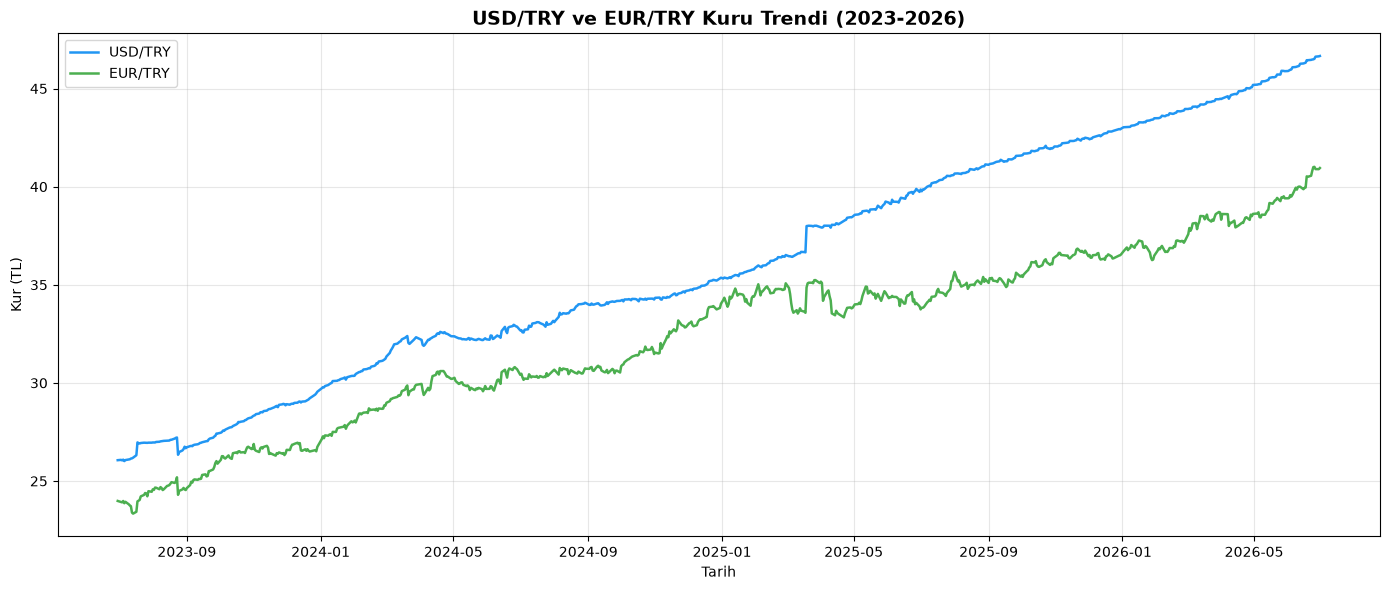

✅ Grafik kaydedildi!


In [14]:
import os
os.makedirs("../data", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

df.to_csv("../data/doviz_kurlari.csv", index=False, encoding="utf-8-sig")
print(f"✅ Veri kaydedildi! {len(df)} satır")

import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (14, 6)

fig, ax = plt.subplots()
ax.plot(df["tarih"], df["USD_TRY"], label="USD/TRY", color="#2196F3", linewidth=1.8)
ax.plot(df["tarih"], df["EUR_TRY"], label="EUR/TRY", color="#4CAF50", linewidth=1.8)

ax.set_title("USD/TRY ve EUR/TRY Kuru Trendi (2023-2026)", fontsize=14, fontweight="bold")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kur (TL)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/01_doviz_trend.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi!")

In [15]:
# Günlük yüzdesel değişim (getiri)
df["USD_TRY_getiri"] = df["USD_TRY"].pct_change() * 100

# 30 günlük hareketli ortalama
df["USD_TRY_MA30"] = df["USD_TRY"].rolling(window=30).mean()

# Temel istatistikler
print("=== USD/TRY İSTATİSTİKLERİ ===")
print(f"Başlangıç değeri: {df['USD_TRY'].iloc[0]:.2f}")
print(f"Son değer: {df['USD_TRY'].iloc[-1]:.2f}")
print(f"Toplam değişim: %{((df['USD_TRY'].iloc[-1]/df['USD_TRY'].iloc[0])-1)*100:.1f}")
print(f"En yüksek: {df['USD_TRY'].max():.2f}")
print(f"En düşük: {df['USD_TRY'].min():.2f}")
print(f"Ortalama günlük volatilite: %{df['USD_TRY_getiri'].std():.2f}")

=== USD/TRY İSTATİSTİKLERİ ===
Başlangıç değeri: 26.06
Son değer: 46.66
Toplam değişim: %79.0
En yüksek: 46.66
En düşük: 26.02
Ortalama günlük volatilite: %0.26


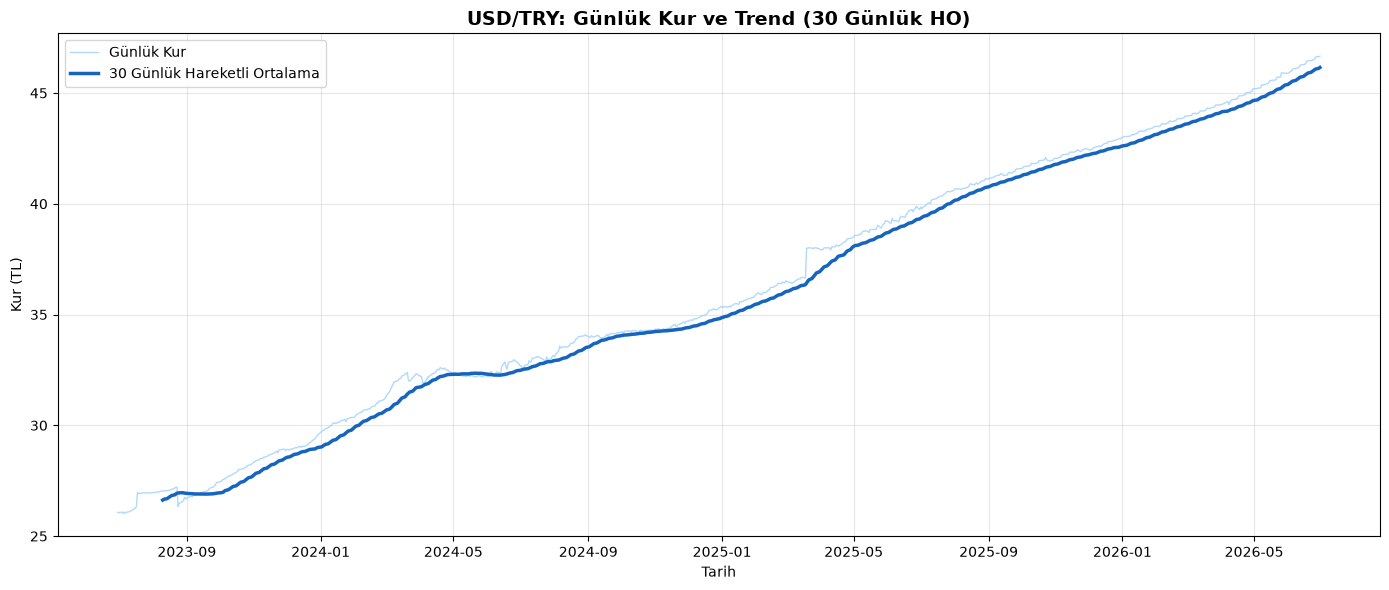

✅ Grafik kaydedildi!


In [16]:
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(df["tarih"], df["USD_TRY"], label="Günlük Kur", color="#90CAF9", linewidth=1, alpha=0.7)
ax.plot(df["tarih"], df["USD_TRY_MA30"], label="30 Günlük Hareketli Ortalama", color="#1565C0", linewidth=2.5)

ax.set_title("USD/TRY: Günlük Kur ve Trend (30 Günlük HO)", fontsize=14, fontweight="bold")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kur (TL)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/02_usd_try_hareketli_ortalama.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi!")

      ortalama_kur  min_kur  max_kur  volatilite
yil                                             
2023         27.65    26.02    29.55        0.39
2024         32.87    29.73    35.36        0.24
2025         39.57    35.32    42.96        0.26
2026         44.64    43.03    46.66        0.09


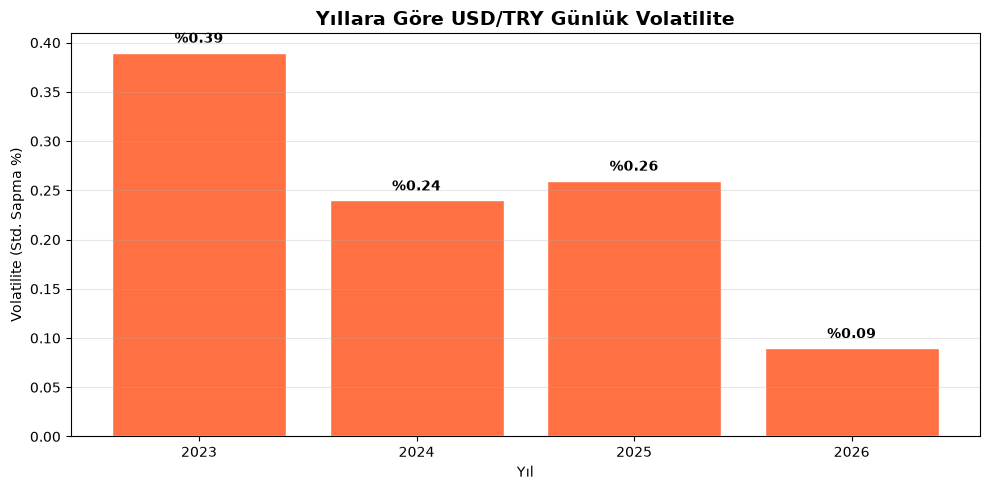

✅ Grafik kaydedildi!


In [17]:
df["yil"] = df["tarih"].dt.year

yillik_ozet = df.groupby("yil").agg(
    ortalama_kur=("USD_TRY", "mean"),
    min_kur=("USD_TRY", "min"),
    max_kur=("USD_TRY", "max"),
    volatilite=("USD_TRY_getiri", "std")
).round(2)

print(yillik_ozet)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(yillik_ozet.index.astype(str), yillik_ozet["volatilite"], color="#FF7043", edgecolor="white")

for bar, val in zip(bars, yillik_ozet["volatilite"]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"%{val:.2f}", ha="center", fontweight="bold")

ax.set_title("Yıllara Göre USD/TRY Günlük Volatilite", fontsize=14, fontweight="bold")
ax.set_xlabel("Yıl")
ax.set_ylabel("Volatilite (Std. Sapma %)")
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.savefig("../outputs/03_yillik_volatilite.png", dpi=150)
plt.show()
print("✅ Grafik kaydedildi!")

# 💱 USD/TRY ve EUR/TRY Döviz Kuru Analizi

Bu notebook, Frankfurter API üzerinden çekilen gerçek döviz kuru verileriyle
2023-2026 yılları arasındaki USD/TRY ve EUR/TRY trendini, volatilitesini
ve basit bir regresyon modeliyle kısa vadeli projeksiyonunu incelemektedir.

In [20]:
from sklearn.linear_model import LinearRegression
import numpy as np

# Tarihi sayısal değere çevirelim (gün indeksi)
df_model = df.dropna(subset=["USD_TRY"]).copy()
df_model["gun_index"] = (df_model["tarih"] - df_model["tarih"].min()).dt.days

X = df_model[["gun_index"]]
y = df_model["USD_TRY"]

model = LinearRegression()
model.fit(X, y)

# Gelecek 30 gün için tahmin
son_gun = df_model["gun_index"].max()
gelecek_gunler = np.arange(son_gun + 1, son_gun + 31).reshape(-1, 1)
tahminler = model.predict(gelecek_gunler)

gelecek_tarihler = pd.date_range(start=df_model["tarih"].max() + pd.Timedelta(days=1), periods=30)
tahmin_df = pd.DataFrame({"tarih": gelecek_tarihler, "tahmin_USD_TRY": tahminler})

print(f"✅ Model eğitildi! R² skoru: {model.score(X, y):.3f}")
print(f"\n30 gün sonraki tahmini kur: {tahminler[-1]:.2f} TL")
tahmin_df.head()

✅ Model eğitildi! R² skoru: 0.993

30 gün sonraki tahmini kur: 46.82 TL


C:\Users\eliff\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


,tarih,tahmin_USD_TRY
0,2026-07-01,46.281152
1,2026-07-02,46.299580
2,2026-07-03,46.318008
3,2026-07-04,46.336436
4,2026-07-05,46.354864


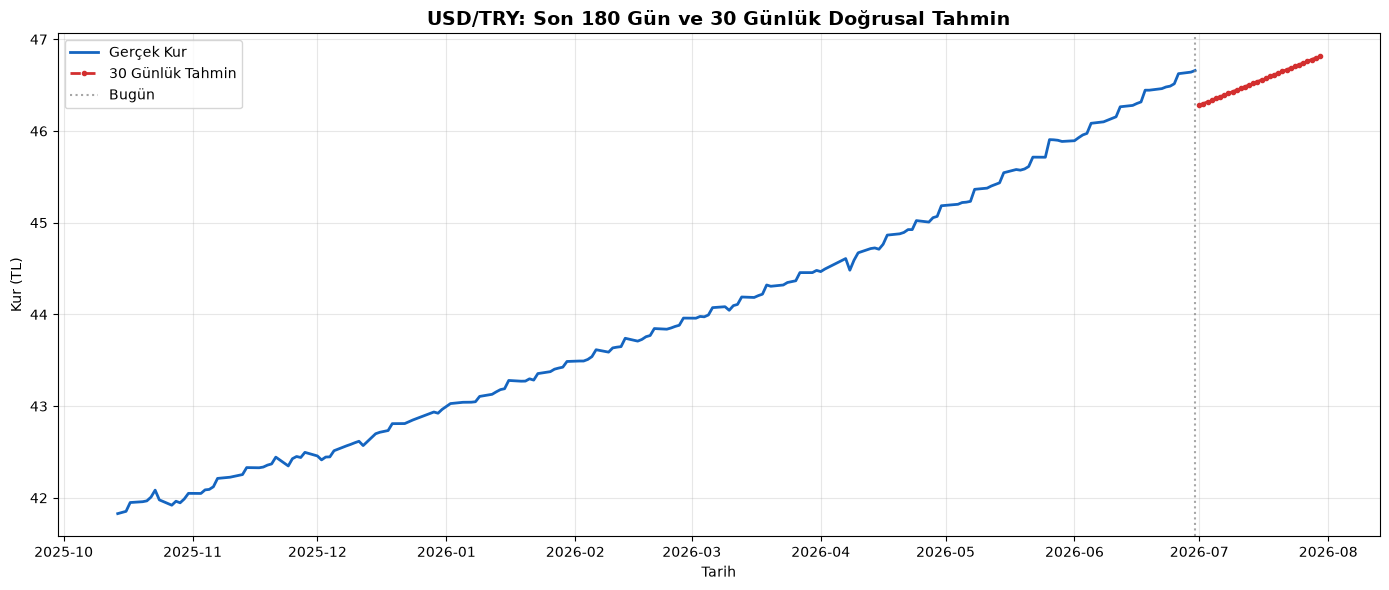

✅ Tahmin grafiği kaydedildi!


In [21]:
fig, ax = plt.subplots(figsize=(14, 6))

# Son 180 günü göster (daha net görünüm için)
son_180 = df_model.tail(180)
ax.plot(son_180["tarih"], son_180["USD_TRY"], label="Gerçek Kur", color="#1565C0", linewidth=2)
ax.plot(tahmin_df["tarih"], tahmin_df["tahmin_USD_TRY"], label="30 Günlük Tahmin", 
        color="#D32F2F", linewidth=2, linestyle="--", marker="o", markersize=3)

ax.axvline(x=df_model["tarih"].max(), color="gray", linestyle=":", alpha=0.7, label="Bugün")
ax.set_title("USD/TRY: Son 180 Gün ve 30 Günlük Doğrusal Tahmin", fontsize=14, fontweight="bold")
ax.set_xlabel("Tarih")
ax.set_ylabel("Kur (TL)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("../outputs/04_tahmin_modeli.png", dpi=150)
plt.show()
print("✅ Tahmin grafiği kaydedildi!")

## 📝 Sonuç ve Değerlendirme

Bu analizde 2023-2026 yılları arasındaki USD/TRY kuru incelenmiş ve şu bulgulara ulaşılmıştır:

- **Trend:** Dolar, 3 yılda TL karşısında %79 değer kazanmıştır.
- **Volatilite:** 2023 yılı en dalgalı dönem olmuş (%0.39), 2026'da bu oran %0.09'a gerilemiştir; bu durum kur artışının daha "kontrollü" bir seyre girdiğini gösterebilir.
- **Tahmin modeli:** Basit doğrusal regresyon, mevcut trendin devam etmesi varsayımıyla 30 gün sonrası için ~46.82 TL öngörmektedir. Bu model doğrusal bir yaklaşım olduğundan ani ekonomik şokları (faiz kararları, jeopolitik olaylar vb.) hesaba katmaz; sadece kısa vadeli trend devamlılığı varsayımına dayanır.

**Not:** Bu analiz yatırım tavsiyesi değildir, yalnızca veri analizi pratiği amacıyla hazırlanmıştır.